# Power Spectra with Smoothing

A notebook to explore the effects of beam smoothing on power spectra.

Based on the Power Spectrum Analysis Notebook from CMB summer schools

In [58]:
import numpy as np
import matplotlib
import sys
import matplotlib.cm as cm
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import astropy.units as u
import pickle as pkl
import matplotlib

matplotlib.style.use("/shared_home/henachman/.matplotlib/stylelib/HNCustomMono.mplstyle")

import constants as cs # the constants module
import cmb_modules # the module of functions

N = cs.N
c_min = cs.c_min
c_max = cs.c_max
X_width =cs.X_width
Y_width = cs.Y_width
beam_size_fwhp = cs.beam_size_fwhp

pix_size = cs.pix_size

Number_of_Sources  = cs.Number_of_Sources
Amplitude_of_Sources = cs.Amplitude_of_Sources
Number_of_Sources_EX = cs.Number_of_Sources_EX
Amplitude_of_Sources_EX = cs.Amplitude_of_Sources_EX

Number_of_SZ_Clusters  = cs.Number_of_SZ_Clusters
Mean_Amplitude_of_SZ_Clusters = cs.Mean_Amplitude_of_SZ_Clusters
SZ_beta = cs.SZ_beta
SZ_Theta_core = cs.SZ_Theta_core

white_noise_level = cs.white_noise_level
atmospheric_noise_level = cs.atmospheric_noise_level
one_over_f_noise_level = cs.one_over_f_noise_level

Make one function to recalculate results from previous stages but for a set FWHM

In [59]:
def cosine_window(N):
  "makes a cosine window for apodizing to avoid edges effects in the 2d FFT" 
  # make a 2d coordinate system
  N=int(N) 
  ones = np.ones(N)
  inds  = (((np.arange(N)+.5 - N/2.)/N) *np.pi) ## eg runs from -pi/2 to pi/2
  X = np.outer(ones,inds)
  Y = np.transpose(X)

  # make a window map
  window_map = np.cos(X) * np.cos(Y)
  
  # return the window map
  return(window_map)
###############################

def calculate_2d_spectrum(Map1,Map2,delta_ell,ell_max,pix_size,N):
  "calcualtes the power spectrum of a 2d map by FFTing, squaring, and azimuthally averaging"
  ell_min = 0
  N=int(N)
  # make a 2d ell coordinate system
  ones = np.ones(N)
  inds  = (np.arange(N)+.5 - N/2.) /(N-1.)
  kX = np.outer(ones,inds) / (pix_size/60. * np.pi/180.)
  kY = np.transpose(kX)
  K = np.sqrt(kX**2. + kY**2.)
  ell_scale_factor = 2. * np.pi 
  ell2d = K * ell_scale_factor
  
  # make an array to hold the power spectrum results
  N_bins = int((ell_max-ell_min)/delta_ell)
  ell_array = np.arange(N_bins)
  CL_array = np.zeros(N_bins)
  
  # get the 2d fourier transform of the map
  FMap1 = np.fft.ifft2(np.fft.fftshift(Map1))
  FMap2 = np.fft.ifft2(np.fft.fftshift(Map2))
  PSMap = np.fft.fftshift(np.real(np.conj(FMap1) * FMap2))
  # fill out the spectra

  for i in range(N_bins):
      ell_array[i] = (i + 0.5) * delta_ell + ell_min
      inds_in_bin = ((ell2d >= (i*delta_ell  + ell_min)) * (ell2d < ((i+1)* delta_ell + ell_min))).nonzero()
      CL_array[i] = np.mean(PSMap[inds_in_bin])

  # return the power spectrum and ell bins
  return(ell_array,CL_array*(pix_size /60.* np.pi/180.) /4)


def get_fsky(pix_size, N, window=1):
  """
  Corrects the power spectrum for using only a small patch of the sky.
  """
  patch_area = (pix_size / 60 * np.pi / 180)**2 * N**2
  window_fsky = np.mean(window**2)
  return patch_area  / (4 * np.pi) * window_fsky

# This function takes multiple spectra and averages them
def average_N_spectra(spectra):
    avgSpectra = np.mean(spectra, axis=0)
    rmsSpectra = np.std(spectra, axis=0)
    return avgSpectra, rmsSpectra


In [60]:
def b_ell(ell_arr, fwhm):
    """
    assumes fwhm in arcmin
    """
    fwhm_rad = ((fwhm * u.arcmin).to(u.rad)).value
    print(fwhm_rad)

    first_term = (np.array(ell_arr)*(np.array(ell_arr)+1))/(2)
    print(f"First Term {first_term}")
    second_term = (fwhm_rad/(8*np.log(2)))
    print(f"Second Term {second_term}")

    b_ell_raw = np.exp(-first_term * second_term)

    norm_value = b_ell_raw[0]
    b_ell_norm = b_ell_raw/norm_value
    return b_ell_norm 

In [61]:
def make_noise_spectrum(ell_max, delta_ell, window):
    # Make a noise realization
    N_iterations = 16

    noise_only  = np.zeros([N_iterations,int(ell_max/delta_ell)])
    for i in range(N_iterations):
        Noise = cmb_modules.make_noise_map(N,pix_size,white_noise_level,atmospheric_noise_level,one_over_f_noise_level)
        binned_ell_cur, binned_spectrum_cur = calculate_2d_spectrum(Noise*window,Noise*window,delta_ell,ell_max,pix_size,N)
        noise_only[i,:] = binned_spectrum_cur
        sys.stdout.write("\r noise only sims, iterations complete: %d of %d" % ((i+1),N_iterations) )
        sys.stdout.flush()

    noise_only_mean_spectrum, _ = average_N_spectra(noise_only)

    return noise_only_mean_spectrum

In [94]:
def make_corrected_powerspectrum(beam_size_fwhp, noise_only_mean_spectrum=None, ax=None):
    ## Make a CMB map
    ell, DlTT = np.loadtxt("CAMB_scalCls_fiducial.dat", usecols=(0, 1), unpack=True) 
    CMB_T = cmb_modules.make_CMB_T_map(N,pix_size,ell,DlTT)

    ## make a point source map
    PSMap = cmb_modules.Poisson_source_component(N,pix_size,Number_of_Sources,Amplitude_of_Sources) 
    PSMap +=  cmb_modules.Exponential_source_component(N,pix_size,Number_of_Sources_EX,Amplitude_of_Sources_EX)

    ## make an SZ map
    SZMap,SZCat = cmb_modules.SZ_source_component(N,pix_size,Number_of_SZ_Clusters,Mean_Amplitude_of_SZ_Clusters,SZ_beta,SZ_Theta_core,False)

    ## add them all together to get the sky map at a single freuqency
    total_map = CMB_T + PSMap + SZMap

    ## incorperate the impact of the instrument
        ## beam
    CMB_T_convolved = cmb_modules.convolve_map_with_gaussian_beam(N,pix_size,beam_size_fwhp,total_map)
        ## noise
    Noise = cmb_modules.make_noise_map(N,pix_size,white_noise_level,atmospheric_noise_level,one_over_f_noise_level)

    total_map_plus_noise = CMB_T_convolved + Noise

    ## plot the result
    # p=cmb_modules.Plot_CMB_Map(total_map_plus_noise,c_min,c_max,X_width,Y_width)



    window = (cosine_window(N))
        
    apodized_map = window * total_map_plus_noise

    # p=cmb_modules.Plot_CMB_Map(apodized_map,c_min,c_max,X_width,Y_width)

    #### parameters for setting up the spectrum
    delta_ell = 50.
    # ell_min = 100.
    ell_max = 5000.

    if max(ell)< ell_max: 
        print('WARNING: Your theory curves end before the binned ell_max')

    ## make a power spectrum
    binned_ell, binned_spectrum = calculate_2d_spectrum(apodized_map,apodized_map,delta_ell,ell_max,pix_size,N)

    # to go from Cl to Dl
    fac_binned = binned_ell * (binned_ell+1.) /2. / np.pi

    # Include noise
    if noise_only_mean_spectrum is None:
        noise_only_mean_spectrum = make_noise_spectrum(ell_max, delta_ell, window)


    # Beam convolution
    # print(binned_ell)
    # binned_spectrum = binned_spectrum*(b_ell(binned_ell, beam_size_fwhp)**2)
    # print("Bell result: ", b_ell(binned_ell, beam_size_fwhp))
    # Sky frac
    fac_binned_skyfrac = binned_spectrum* fac_binned / get_fsky(pix_size, N, window=window)
    noise_spectrum_skyfrac = noise_only_mean_spectrum* fac_binned / get_fsky(pix_size, N, window=window)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(ell,DlTT, label=r"Input $C_\ell$", color="black")
    # ax.plot(binned_ell,fac_binned_skyfrac, label=r"Measured $\hat{C}_\ell + N_\ell$")
    # ax.plot(binned_ell,noise_spectrum_skyfrac, label=r"Monte Carlo $N_\ell$")
    ax.plot(binned_ell,fac_binned_skyfrac - noise_spectrum_skyfrac, label=r"Corrected $\hat{C}_\ell$, $\theta_{FWHM}=$"+f"{beam_size_fwhp}'")

    ax.set_ylabel(r'$D_{\ell}$ [$\mu$K$^2$]', fontsize=18)
    ax.set_xlabel(r'$\ell$', fontsize=18)
    ax.set_yscale("log")
    ax.set_xlim(-100, 5100)
    # ax.set_ylim(0.001, 10000)
    ax.legend(fontsize=12)
    ax.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)

    ax2 = ax.twiny()


    # Find the indeces of the following ells
    ell_to_find = np.array([1000, 2000, 3000, 4000, 5000])
    # make the new x ticks 
    # ax2.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax2.set_xticks(ell_to_find, 180*60/ell_to_find)
    ax2.set_xlim(-100, 5100)
    ax2.set_xlabel(r"$\theta$ (')")

    # ax2.xaxis.set_label_position('top')
    return ax, noise_only_mean_spectrum

/shared_home/henachman/SO_PointingReqs/CMB_sims/cmb_modules.py:15: RuntimeWarning: invalid value encountered in divide
  ClTT = DlTT * 2 * np.pi / (ell * (ell + 1.0))


Number of sources required:  5000


/shared_home/henachman/SO_PointingReqs/CMB_sims/cmb_modules.py:15: RuntimeWarning: invalid value encountered in divide
  ClTT = DlTT * 2 * np.pi / (ell * (ell + 1.0))


Number of sources required:  5000


/shared_home/henachman/SO_PointingReqs/CMB_sims/cmb_modules.py:15: RuntimeWarning: invalid value encountered in divide
  ClTT = DlTT * 2 * np.pi / (ell * (ell + 1.0))


Number of sources required:  5000


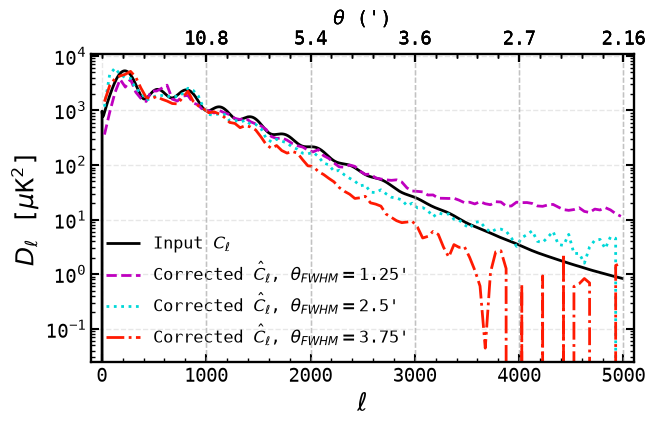

In [95]:
# save the noms as a pkl just so I don't have to keep running it

with open("noise_only_mean_spectrum.pkl", "rb") as file:
    noms = pkl.load(file)

new_ax, _ = make_corrected_powerspectrum(beam_size_fwhp, noms)
_ = make_corrected_powerspectrum(2*beam_size_fwhp, noms, ax = new_ax)
_ = make_corrected_powerspectrum(3*beam_size_fwhp, noms, ax = new_ax)

# with open("noise_only_mean_spectrum.pkl", "wb") as file:
#     pkl.dump(noms, file)
# beam_size_fwhp = 2.5
# make_corrected_powerspectrum(beam_size_fwhp, noms)
